# Importing

In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
# ------------ SETS PATH ------------ #
currentdir = os.getcwd()
parentdir = os.path.dirname(currentdir)

# ------------ FILES CURRENTDIR ------------ #
sys.path.insert(0, currentdir)

# ------------ FILES PARENTDIR ------------ #
sys.path.insert(0, parentdir)
import AuxiliaryFunctions as aux
from NFW_class import NFW_profile, r1
import Config as cfg
from ISO_and_NFW import ISO_and_NFW
from Isothermal_paper_2206 import findTwoDeltaMinimum
from CoreNFW_class import find_fitting_parm, coreNFW

In [2]:
nums_r = 10
r_start = 1
r_end = 100
r = np.logspace(np.log10(r_start), np.log10(r_end), nums_r)  # (array) [kpc]


coreNFW_data = dict()
coreNFW_data["r"] = np.array([])
coreNFW_data["r"] = np.append(coreNFW_data["r"], r)

print("r:", r)
print("coreNFW_data['r']:", coreNFW_data["r"])

r: [  1.           1.66810054   2.7825594    4.64158883   7.74263683
  12.91549665  21.5443469   35.93813664  59.94842503 100.        ]
coreNFW_data['r']: [  1.           1.66810054   2.7825594    4.64158883   7.74263683
  12.91549665  21.5443469   35.93813664  59.94842503 100.        ]


# SETS OF SIMULATION: USER SETS!

In [3]:
sigma_m = 1.0  # [cm^2/g] annihilation cross-section
sigma_m_SI = sigma_m * 10**(-4) * 10**3  # [m^2/kg]
M_vir = 5*10**10.0  # [M_sun] Viral mass
const_c = aux.DMc_gravo(M_vir, 0, cfg.const_h)  # [dimensionless] concentration of DM
# const_c = 15.0  # [dimensionless] concentration of DM

# CREATING NFW CLASS: USER SETS!

In [4]:
NFW_profile = NFW_profile(M_vir, const_c)
r_s = NFW_profile.r_s
rounded_r_s = cfg.rounded_number(r_s, 3)

rho_s = NFW_profile.rho_s
rounded_rho_s = cfg.rounded_number(rho_s, 3)
print(f"rho_s = {rounded_rho_s} [M_solar / kpc^3], r_s = {rounded_r_s} [kpc]")
print(f"dark matter concentration: {const_c}")

rho_s = 7590000.0 [M_solar / kpc^3], r_s = 6.9 [kpc]
dark matter concentration: 11.3215282619091


In [5]:
# Here we set the value of radiuses: USER CONTROL!

nums_r = 300  # for how many radius we want data in .txt  file
r_tilda_start = 0.01  # [dimensionless]
r_tilda_end = 100.0  # [dimensionless]
r_start = aux.convert_r_tilda(r_tilda_start, r_s)  # [kpc]
r_end = aux.convert_r_tilda(r_tilda_end, r_s)  # [kpc]
# list which contains radius
r_list = np.logspace(np.log10(r_start), np.log10(r_end), nums_r)  # (array) [kpc]

In [6]:
# Set the value of time: USER CONTROL!

time_tilda_start = 6*10**(-1)  # [dimensionless]
time_tilda_end = 540.0  # [dimensionless]
# tage_tilda belongs to [time_tilda_start, time_tilda_end]
tage_tilda = 450
tage = aux.convert_time_tilda(tage_tilda, rho_s, r_s, sigma_m)  # [Gyr]

# calculate r1
r_1 = r1(NFW_profile, sigmamx=sigma_m, tage=tage)
print("r_1:", r_1)

r_1: 29.22989671056613


In [7]:
# Here we save data from `NFW`
NFW_data = dict()
NFW_data['r'] = r_list
NFW_data['rho'] = NFW_profile.rho(r_list)
NFW_data['mass'] = NFW_profile.Mass(r_list)
NFW_data['velDis'] = NFW_profile.sigma_accurate(r_list)

# ISOTHERMAL

In [8]:
SIDM_LoDens, SIDM_HiDens = findTwoDeltaMinimum(r_1, NFW_profile)  # by default r_low=-3.

In [9]:
# now put important parameters in one list
tmerge = tage # we won't use in calculation

par_dict = dict()
par_dict['Mvir'] = M_vir
par_dict['c_const'] = const_c
par_dict['r1'] = r_1
par_dict['t'] = tmerge

# data from Isothermal evolution
rho0 = SIDM_LoDens[0]  # [M_sun/kpc^3]
nu0 = SIDM_LoDens[1]  # [kpc/Gyr]

print(f'central DM density: {rho0} [M_sun/kpc^3]')
print(f'central DM velocity dispersion: {nu0} [kpc/Gyr]')

# data from Isothermal model
radius_ISO = np.array(SIDM_LoDens[4])
density_ISO = np.array(SIDM_LoDens[2])
mass_ISO = np.array(SIDM_LoDens[5])

ISO_data = dict()
ISO_data['Lo'] = dict()
ISO_data['Lo']["r"] = radius_ISO
ISO_data['Lo']["rho"] = density_ISO
ISO_data['Lo']["mass"] = mass_ISO

radius_ISO = np.array(SIDM_HiDens[4])
density_ISO = np.array(SIDM_HiDens[2])
mass_ISO = np.array(SIDM_HiDens[5])

ISO_data['Hi'] = dict()
ISO_data['Hi']["r"] = radius_ISO
ISO_data['Hi']["rho"] = density_ISO
ISO_data['Hi']["mass"] = mass_ISO

central DM density: 19053614.754731055 [M_sun/kpc^3]
central DM velocity dispersion: 42.52273250252389 [kpc/Gyr]


# ISOTHERMAL and NFW

In [10]:
ISO_and_NFW_class = ISO_and_NFW([ISO_data['Lo']["r"],ISO_data['Lo']["rho"], ISO_data['Lo']["mass"]],par_dict)

In [11]:
# Here we save data from `ISO and NFW`
ISO_and_NFW_data = dict()
ISO_and_NFW_data["r"] = r_list
ISO_and_NFW_data["rho"] = ISO_and_NFW_class.rho_return(r_list)
ISO_and_NFW_data["mass"] = ISO_and_NFW_class.M_enclosed_return(r_list)
ISO_and_NFW_data["velDis"] = ISO_and_NFW_class.velDis(r_list)

C:\Users\Krzysztof\Documents\GitHub\DarkMatterProfiles\R-procedure\NFW-Isothermal-paper-2206\ISO_and_NFW.py:431: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  I = quad(f, r, self.r1, epsabs=1.e-7, epsrel=1.e-6, limit=10000)[0]


nu_square_1a: 1839.6624540825123
nu_square_1b: 4.65436153051679
step: 0
nu_square_1a: 1839.668886426579
nu_square_1b: 4.654501045133587
step: 1
nu_square_1a: 1839.6624480125956
nu_square_1b: 4.654649922952126
step: 2
nu_square_1a: 1839.6697092407267
nu_square_1b: 4.6548077472754965
step: 3
nu_square_1a: 1839.6764327756093
nu_square_1b: 4.654976140111957
step: 4
nu_square_1a: 1839.6768841979667
nu_square_1b: 4.655154677650015
step: 5
nu_square_1a: 1839.6737976082586
nu_square_1b: 4.655345144042991
step: 6
nu_square_1a: 1839.6670593424983
nu_square_1b: 4.655547113945339
step: 7
nu_square_1a: 1839.6657122286692
nu_square_1b: 4.655762548334059
step: 8
nu_square_1a: 1839.6643148555693
nu_square_1b: 4.655991027104243
step: 9
nu_square_1a: 1839.6531612832991
nu_square_1b: 4.656234703517607
step: 10
nu_square_1a: 1839.6571305524346
nu_square_1b: 4.656493171557476
step: 11
nu_square_1a: 1839.6433922622673
nu_square_1b: 4.656768793740602
step: 12
nu_square_1a: 1839.6693320736388
nu_square_1b: 4.

nu_square_1a: 1836.4907739404632
nu_square_1b: 7.029962629950412
step: 112
nu_square_1a: 1836.2600442216562
nu_square_1b: 7.193673829592066
step: 113
nu_square_1a: 1836.035216134727
nu_square_1b: 7.3694675192343855
step: 114
nu_square_1a: 1835.765896660575
nu_square_1b: 7.55808405866453
step: 115
nu_square_1a: 1835.5090027948745
nu_square_1b: 7.760834416236269
step: 116
nu_square_1a: 1835.1907841897728
nu_square_1b: 7.978512201440213
step: 117
nu_square_1a: 1834.904532020235
nu_square_1b: 8.212751754073762
step: 118
nu_square_1a: 1834.5288463336115
nu_square_1b: 8.464411223722335
step: 119
nu_square_1a: 1834.1916366577518
nu_square_1b: 8.735509290735497
step: 120
nu_square_1a: 1833.7729004377547
nu_square_1b: 9.026985664554799
step: 121
nu_square_1a: 1833.3749880289238
nu_square_1b: 9.341312187529732
step: 122
nu_square_1a: 1832.861392987952
nu_square_1b: 9.679535275223499
step: 123
nu_square_1a: 1832.4252450173014
nu_square_1b: 10.04465642969103
step: 124
nu_square_1a: 1831.8350042911

# Here we will use previous resul to get approximation (coreNFW)

In [12]:
r_c = find_fitting_parm(ISO_and_NFW_class, r_list)[0]
print(f"after calculations we find out that best fitting we get when r_c = {r_c} [kpc]")

after calculations we find out that best fitting we get when r_c = 2.3417673677448074 [kpc]


In [13]:
# working a little bit with the core NFW
coreNFW_class = coreNFW(M_vir, const_c, r_c)

In [14]:
# Here we save data from `core NFW`
coreNFW_data = dict()
coreNFW_data["r"] = r_list
coreNFW_data["rho"] = coreNFW_class.rho(r_list)
coreNFW_data["mass"] = coreNFW_class.M(r_list)
coreNFW_data["velDis"] = coreNFW_class.sigma_accurate(r_list)

# ----------------------------------------- Plot: density -----------------------------------------

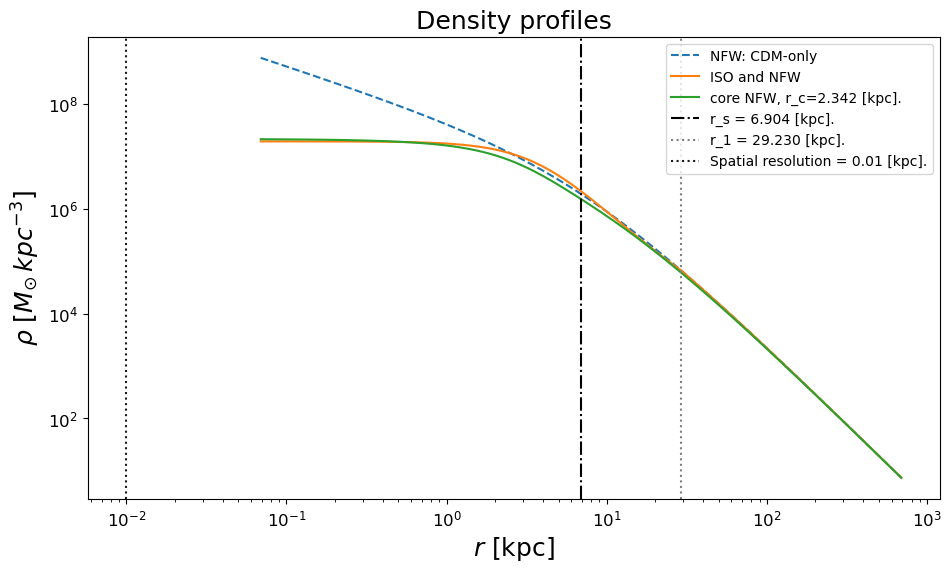

In [15]:
#------------------------------ LINES ------------------------------#
Rres = 0.01

#------------------------------ PLOTTING ------------------------------#
fig, ax = plt.subplots(figsize=(11.0, 6.0))
ax.plot(r_list, NFW_data['rho'], '--', label="NFW: CDM-only")
ax.plot(r_list, ISO_and_NFW_data["rho"], label="ISO and NFW")
ax.plot(r_list, coreNFW_data["rho"], label=f'core NFW, r_c={"{:.3f}".format(r_c)} [kpc].')

# ax.plot(ISO_data['Lo']["r"], ISO_data['Lo']["rho"], label="ISO: low dense")
# ax.plot(ISO_data['Hi']["r"], ISO_data['Hi']["rho"], label="ISO: high dense")

# ax.plot(r_HiDens, rho_HiDens,label="SIDM: high density")

# lines
plt.axvline(x=r_s, color='black', linestyle = 'dashdot',
                    label=f'r_s = {"{:.3f}".format(r_s)} [kpc].')
plt.axvline(x=r_1, color='grey', linestyle = 'dotted',
                    label=f'r_1 = {"{:.3f}".format(r_1)} [kpc].')
plt.axvline(x=Rres, color='black', linestyle = 'dotted', alpha=0.9, 
                    label=f'Spatial resolution = {"{:.2f}".format(Rres)} [kpc].')
# log scale
ax.set_xscale('log')
ax.set_yscale('log')
# describe NFW profile
plt.ylabel(r"$\rho \, \, [M_{\odot} \, kpc^{-3}]$", fontsize=18)
plt.xlabel(r"$r$ [kpc]", fontsize=18)
plt.title("Density profiles", fontsize=18)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.legend()
plt.show()

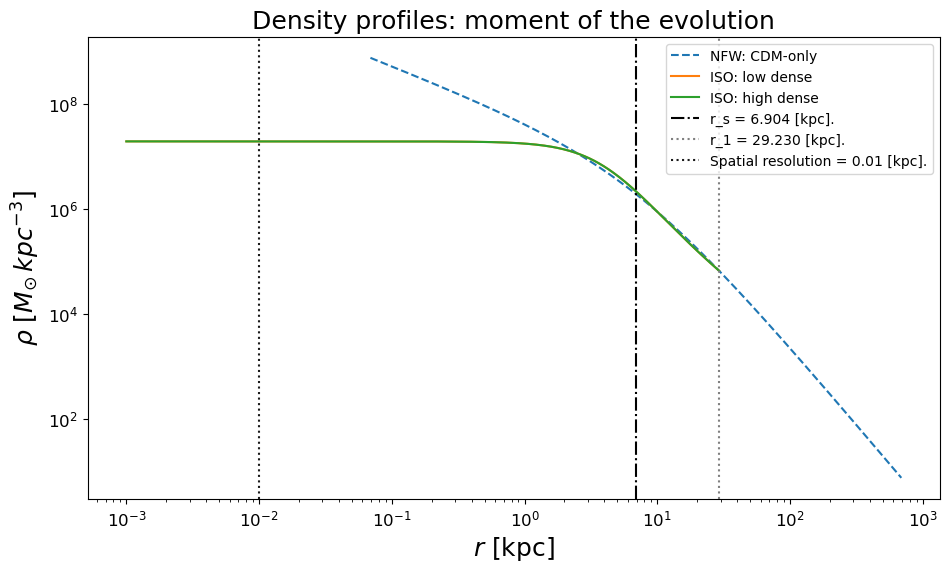

In [16]:
#------------------------------ LINES ------------------------------#
Rres = 0.01

#------------------------------ PLOTTING ------------------------------#
fig, ax = plt.subplots(figsize=(11.0, 6.0))
ax.plot(r_list, NFW_data['rho'], '--', label="NFW: CDM-only")
# ax.plot(r_list, ISO_and_NFW_data["rho"], label="ISO and NFW")
ax.plot(ISO_data['Lo']["r"], ISO_data['Lo']["rho"], label="ISO: low dense")
ax.plot(ISO_data['Hi']["r"], ISO_data['Hi']["rho"], label="ISO: high dense")

# ax.plot(r_HiDens, rho_HiDens,label="SIDM: high density")

# lines
plt.axvline(x=r_s, color='black', linestyle = 'dashdot',
                    label=f'r_s = {"{:.3f}".format(r_s)} [kpc].')
plt.axvline(x=r_1, color='grey', linestyle = 'dotted',
                    label=f'r_1 = {"{:.3f}".format(r_1)} [kpc].')
plt.axvline(x=Rres, color='black', linestyle = 'dotted', alpha=0.9, 
                    label=f'Spatial resolution = {"{:.2f}".format(Rres)} [kpc].')
# log scale
ax.set_xscale('log')
ax.set_yscale('log')
# describe NFW profile
plt.ylabel(r"$\rho \, \, [M_{\odot} \, kpc^{-3}]$", fontsize=18)
plt.xlabel(r"$r$ [kpc]", fontsize=18)
plt.title("Density profiles: moment of the evolution", fontsize=18)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.legend()
plt.show()

# ------------------------------------ Plot: mass ------------------------------------

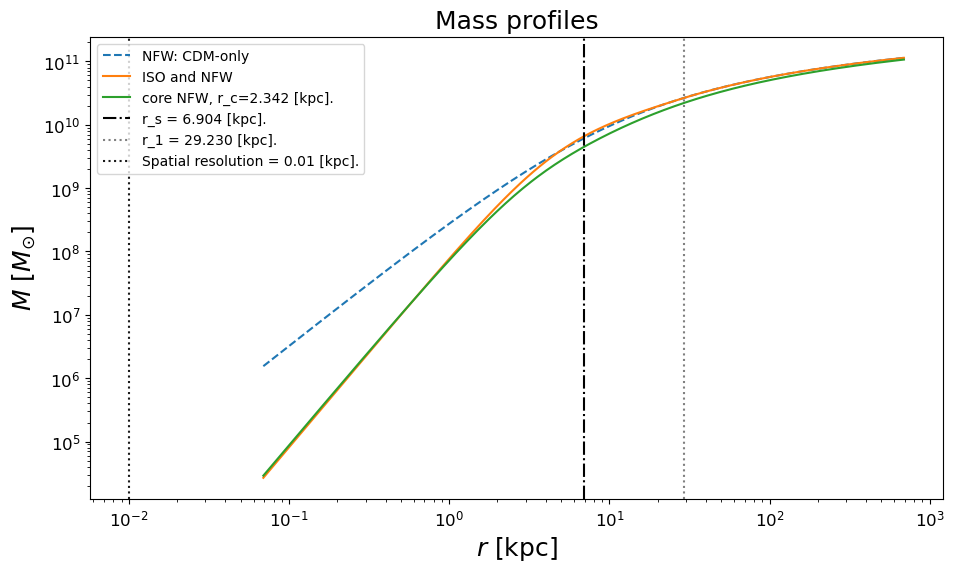

In [17]:
#------------------------------ LINES ------------------------------#
Rres = 0.01

#------------------------------ PLOTTING ------------------------------#
fig, ax = plt.subplots(figsize=(11.0, 6.0))
ax.plot(r_list, NFW_data['mass'], '--', label="NFW: CDM-only")
ax.plot(r_list, ISO_and_NFW_data["mass"], label="ISO and NFW")
ax.plot(r_list, coreNFW_data["mass"], label=f'core NFW, r_c={"{:.3f}".format(r_c)} [kpc].')

# ax.plot(ISO_data['Lo']["r"], ISO_data['Lo']["rho"], label="ISO: low dense")
# ax.plot(ISO_data['Hi']["r"], ISO_data['Hi']["rho"], label="ISO: high dense")

# ax.plot(r_HiDens, rho_HiDens,label="SIDM: high density")

# lines
plt.axvline(x=r_s, color='black', linestyle = 'dashdot',
                    label=f'r_s = {"{:.3f}".format(r_s)} [kpc].')
plt.axvline(x=r_1, color='grey', linestyle = 'dotted',
                    label=f'r_1 = {"{:.3f}".format(r_1)} [kpc].')
plt.axvline(x=Rres, color='black', linestyle = 'dotted', alpha=0.9, 
                    label=f'Spatial resolution = {"{:.2f}".format(Rres)} [kpc].')
# log scale
ax.set_xscale('log')
ax.set_yscale('log')
# describe NFW profile
plt.ylabel(r"$M \, \, [M_{\odot}]$", fontsize=18)
plt.xlabel(r"$r$ [kpc]", fontsize=18)
plt.title("Mass profiles", fontsize=18)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.legend()
plt.show()

# ----------------------------- Plot: velocity dispersion -----------------------------

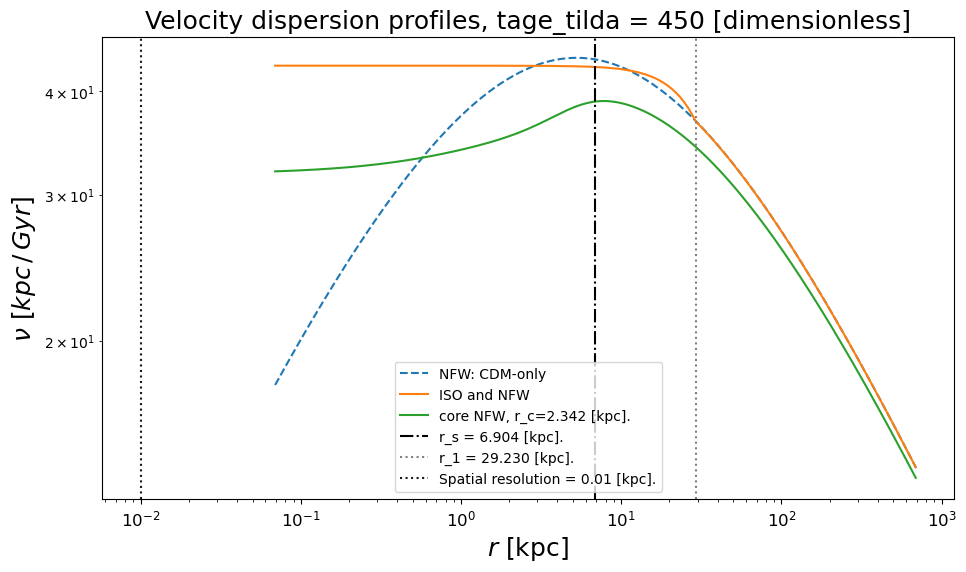

In [18]:
#------------------------------ LINES ------------------------------#
Rres = 0.01

#------------------------------ PLOTTING ------------------------------#
fig, ax = plt.subplots(figsize=(11.0, 6.0))
ax.plot(r_list, NFW_data['velDis'], '--', label="NFW: CDM-only")
ax.plot(r_list, ISO_and_NFW_data["velDis"], label="ISO and NFW")
ax.plot(r_list, coreNFW_data["velDis"], label=f'core NFW, r_c={"{:.3f}".format(r_c)} [kpc].')

# ax.plot(ISO_data['Lo']["r"], ISO_data['Lo']["rho"], label="ISO: low dense")
# ax.plot(ISO_data['Hi']["r"], ISO_data['Hi']["rho"], label="ISO: high dense")

# ax.plot(r_HiDens, rho_HiDens,label="SIDM: high density")

# lines
plt.axvline(x=r_s, color='black', linestyle = 'dashdot',
                    label=f'r_s = {"{:.3f}".format(r_s)} [kpc].')
plt.axvline(x=r_1, color='grey', linestyle = 'dotted',
                    label=f'r_1 = {"{:.3f}".format(r_1)} [kpc].')
plt.axvline(x=Rres, color='black', linestyle = 'dotted', alpha=0.9, 
                    label=f'Spatial resolution = {"{:.2f}".format(Rres)} [kpc].')
# log scale
ax.set_xscale('log')
ax.set_yscale('log')
# describe NFW profile
plt.ylabel(r"$\nu \, \, [kpc \, / \, Gyr]$", fontsize=18)
plt.xlabel(r"$r$ [kpc]", fontsize=18)
plt.title(f"Velocity dispersion profiles, tage_tilda = {tage_tilda} [dimensionless]", fontsize=18)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.legend()
plt.show()